# ♻️ Economía Circular & Gestión de Residuos

Este notebook presenta un análisis exploratorio de la generación,
tratamiento y valorización de residuos sólidos, incluyendo indicadores
de eficiencia y estimaciones de emisiones de CO₂ equivalente.

El objetivo es apoyar la toma de decisiones ambientales mediante
visualizaciones y métricas clave.


In [22]:
#Librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.sankey import Sankey

# sns.set(style="whitegrid")
# plt.rcParams["figure.figsize"] = (10, 5)
# Cambiar a un nuevo directorio (ruta absoluta o relativa)
os.chdir('D:/Josefina/Proyectos/Datascience/residuos')

In [ ]:
#Carga de datos en formato csv
df_gen = pd.read_csv("data/residuos_generados.csv", encoding="latin-1")
df_trat = pd.read_csv("data/residuos_tratados.csv", encoding="latin-1")
factores = pd.read_csv("data/factores_co2.csv")

df_gen["mes"] = pd.to_datetime(df_gen["mes"])
df_trat["mes"] = pd.to_datetime(df_trat["mes"])

print( "Residuos Generados")
print(df_gen)
print("-----------------------------------------------------------------------------")
print( "Residuos Tratados")
print(df_trat)


Residuos Generados
          mes residuo_generado  kg_generados
0  2024-01-01           Carton          1200
1  2024-01-01         Plastico           850
2  2024-01-01           Madera           700
3  2024-01-01        Organicos           300
4  2024-01-01       Peligrosos            50
..        ...              ...           ...
70 2024-12-01         Plastico           360
71 2024-12-01           Madera           650
72 2024-12-01        Organicos            35
73 2024-12-01       Peligrosos            55
74 2024-12-01            Otros             2

[75 rows x 3 columns]
-----------------------------------------------------------------------------
Residuos Tratados
           mes residuo_generado                    destino  kg_tratados
0   2024-01-01           Carton                  Reciclaje         1050
1   2024-01-01         Plastico                  Reciclaje          565
2   2024-01-01         Plastico          Disposicion final          150
3   2024-01-01           Madera   

In [ ]:
# Indicadores generales
total_gen = df_gen["kg_generados"].sum()
total_trat = df_trat["kg_tratados"].sum()

eficiencia = (total_trat / total_gen) * 100 if total_gen > 0 else np.nan

# Vemos los datos (en toneladas)
print(f"Residuos generados: {total_gen/1000:.1f} t")
print(f"Residuos valorizados: {total_trat/1000:.1f} t")
print(f"Eficiencia de valorización: {eficiencia:.1f} %")

Residuos generados: 24.2 t
Residuos valorizados: 17.2 t
Eficiencia de valorización: 71.2 %


In [16]:
# Se calcula el CO2 emitido
# Se deben revisar los factores de emision, pueden ser los correctos pero hay que verificarlos

# Se unen los datos con los factores que estan en otro excel
df_co2 = df_trat.merge(factores, on="destino", how="left")
df_co2["co2"] = df_co2["kg_tratados"] * df_co2["factor_co2"]

co2_gen = df_co2.loc[df_co2["factor_co2"] > 0, "co2"].sum()
co2_evit = abs(df_co2.loc[df_co2["factor_co2"] < 0, "co2"].sum())

# Este es el co2 net
co2_neto = co2_evit - co2_gen

print(f"CO₂ generado: {co2_gen/1000:.1f} t")
print(f"CO₂ evitado: {co2_evit/1000:.1f} t")
print(f"Balance neto: {co2_neto/1000:.1f} t")



CO₂ generado: 2.8 t
CO₂ evitado: 16.5 t
Balance neto: 13.7 t


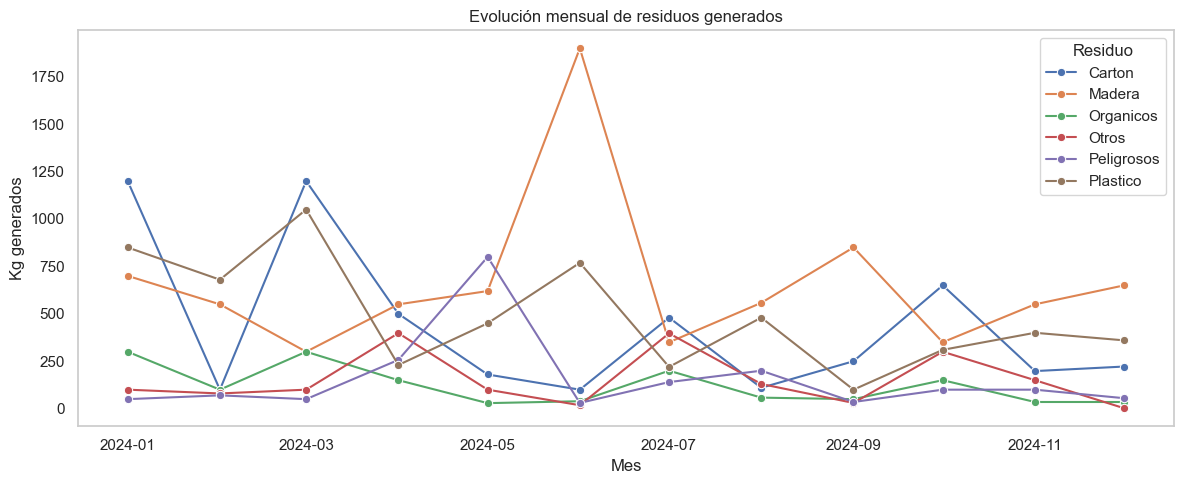

In [19]:
# Serie temporal mensual de los reiduos generados
df_ts = (
    df_gen
    .groupby(["mes", "residuo_generado"], as_index=False)
    .agg(kg_generados=("kg_generados", "sum"))
)


plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_ts,
    x="mes",
    y="kg_generados",
    hue="residuo_generado",
    marker="o"
)
# Plot
plt.title("Evolución mensual de residuos generados")
plt.xlabel("Mes")
plt.ylabel("Kg generados")
plt.legend(title="Residuo")
plt.grid(False)
plt.tight_layout()
plt.show()




C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_16164\2169446246.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


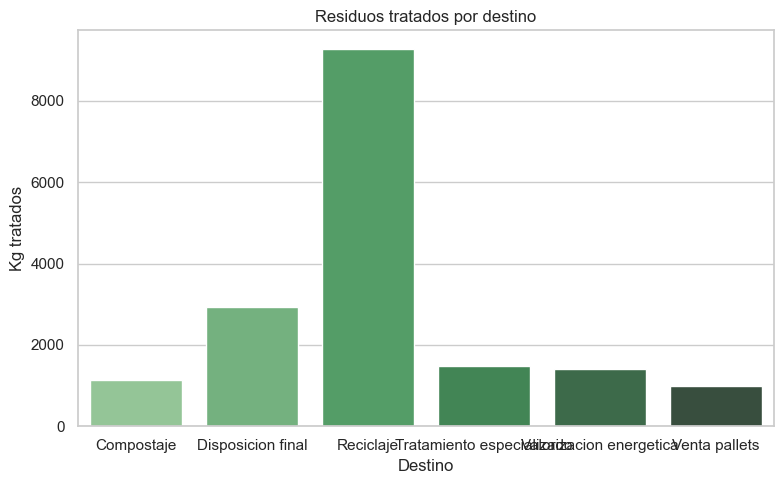

In [ ]:
# Residuos tratados por destino

df_destino = (
    df_trat
    .groupby("destino", as_index=False)
    .agg(kg_tratados=("kg_tratados", "sum"))
)

#Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_destino,
    x="destino",
    y="kg_tratados",
    palette="Greens_d"
)

plt.title("Residuos tratados por destino")
plt.xlabel("Destino")
plt.ylabel("Kg tratados")
plt.tight_layout()
plt.show()



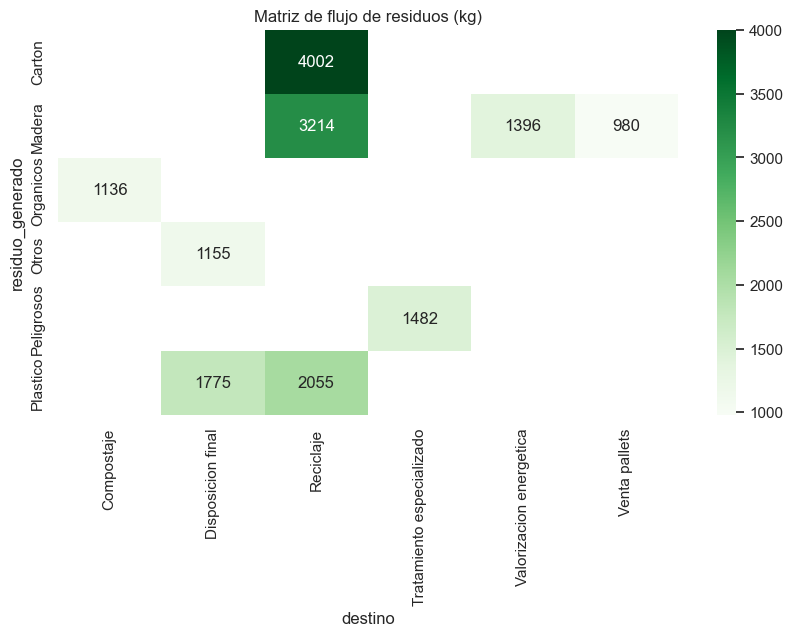

In [28]:
#Matriz de flujo de residuos (KG/TN ver)
resumen_sankey = (
    df_trat
    .groupby(["residuo_generado", "destino"], as_index=False)
    .agg(kg=("kg_tratados", "sum"))
)
tabla = resumen_sankey.pivot(
    index="residuo_generado",
    columns="destino",
    values="kg"
)

sns.heatmap(tabla, annot=True, fmt=".0f", cmap="Greens")
plt.title("Matriz de flujo de residuos (kg)")
plt.grid(False)
plt.show()


In [ ]:
# Alertas sobre la empresa en cuanto a la eficiencia de valorizacion de los residuos
# Los valores objetivos se deberian deterinar en cada caso, este es un ejemplo
alertas = []

if eficiencia < 50:
    alertas.append("⚠️ Eficiencia de valorización menor al 50%")

peligrosos = (
    df_gen.loc[df_gen["residuo_generado"] == "Peligrosos", "kg_generados"]
    .sum()
)

if peligrosos > 500:
    alertas.append("☣️ Alto volumen de residuos peligrosos")



if alertas:
    for alerta in alertas:
        print(alerta)
else:
    print("🟢 Operación dentro de parámetros óptimos")




☣️ Alto volumen de residuos peligrosos


In [ ]:
# Resumen ejecutivo
resumen = f"""
Durante el período analizado se generaron {total_gen/1000:.1f} toneladas de residuos,
de las cuales {total_trat/1000:.1f} toneladas fueron valorizadas, alcanzando una
eficiencia del {eficiencia:.1f}%.

Las estrategias de tratamiento permitieron evitar aproximadamente
{co2_evit/1000:.1f} toneladas de CO₂ equivalente.
"""
print(resumen)




Durante el período analizado se generaron 24.2 toneladas de residuos,
de las cuales 17.2 toneladas fueron valorizadas, alcanzando una
eficiencia del 71.2%.

Las estrategias de tratamiento permitieron evitar aproximadamente
16.5 toneladas de CO₂ equivalente.

